# 1. Загрузка, обработка

In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
files = [f'../data/raw/EURUSD_15min_{year}_Q{quartal}.csv'
         for year in range(2015, 2027)
         for quartal in range(1, 5)]
# оставим только существующие файлы
files = [f for f in files if os.path.exists(f)]

# Чтение и объединение
dfs = [pd.read_csv(f) for f in files]
df = pd.concat(dfs, ignore_index=True)

# Обработка времени
df['timestamp'] = pd.to_datetime(df['timestamp'],utc=False).dt.tz_localize(None)
df = df.drop_duplicates(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)

In [3]:
df.head()

,timestamp,open,high,low,close,volume
0,2014-12-31 18:00:00,1.20997,1.21070,1.20997,1.21048,1118.83
1,2014-12-31 18:15:00,1.21047,1.21079,1.21042,1.21067,523.99
2,2014-12-31 18:30:00,1.21068,1.21069,1.21000,1.21019,690.66
3,2014-12-31 18:45:00,1.21018,1.21018,1.20984,1.21010,725.78
4,2014-12-31 19:00:00,1.21010,1.21037,1.20982,1.20997,750.45


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277105 entries, 0 to 277104
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   timestamp  277105 non-null  datetime64[us]
 1   open       277105 non-null  float64       
 2   high       277105 non-null  float64       
 3   low        277105 non-null  float64       
 4   close      277105 non-null  float64       
 5   volume     277105 non-null  float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 12.7 MB


In [5]:
#поставим timestamp индексом
df.set_index('timestamp', inplace=True)
df.head()

,open,high,low,close,volume
timestamp,,,,,
2014-12-31 18:00:00,1.20997,1.21070,1.20997,1.21048,1118.83
2014-12-31 18:15:00,1.21047,1.21079,1.21042,1.21067,523.99
2014-12-31 18:30:00,1.21068,1.21069,1.21000,1.21019,690.66
2014-12-31 18:45:00,1.21018,1.21018,1.20984,1.21010,725.78
2014-12-31 19:00:00,1.21010,1.21037,1.20982,1.20997,750.45


In [6]:
# 1. returns
df['returns'] = df['close'].pct_change()

# 2. Скользящие средние
df['ma_10'] = df['close'].rolling(10).mean()
df['ma_20'] = df['close'].rolling(20).mean()
df['ma_50'] = df['close'].rolling(50).mean()
# 2.1 Ск.Средние в виде разницы
df['ma_10_diff'] = (df['close'] - df['ma_10']) / df['close']
df['ma_20_diff'] = (df['close'] - df['ma_20']) / df['close']
df['ma_50_diff'] = (df['close'] - df['ma_50']) / df['close']

# 3. Волатильность
df['volatility_20'] = df['returns'].rolling(20).std()

# 4. Время(цикличное)
df['hour_float'] = df.index.hour + df.index.minute / 60

df['time_sin'] = np.sin(2 * np.pi * df['hour_float'] / 24)
df['time_cos'] = np.cos(2 * np.pi * df['hour_float'] / 24)

df['day_of_week'] = df.index.dayofweek

df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# 5. УРОВНИ (support/resistance)
df['rolling_max_50'] = df['high'].rolling(50).max()
df['rolling_min_50'] = df['low'].rolling(50).min()

df['dist_to_res'] = (df['rolling_max_50'] - df['close']) / df['close']
df['dist_to_sup'] = (df['close'] - df['rolling_min_50']) / df['close']

# 6. ПРОБОИ
df['break_res'] = (df['close'] > df['rolling_max_50'].shift(1)).astype(int)
df['break_sup'] = (df['close'] < df['rolling_min_50'].shift(1)).astype(int)

# 7. ИНДИКАТОР RSI
delta = df['close'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df['rsi_14'] = 100 - (100 / (1 + rs))

# 8. УДАЛЕНИЕ NaN
df = df.dropna()

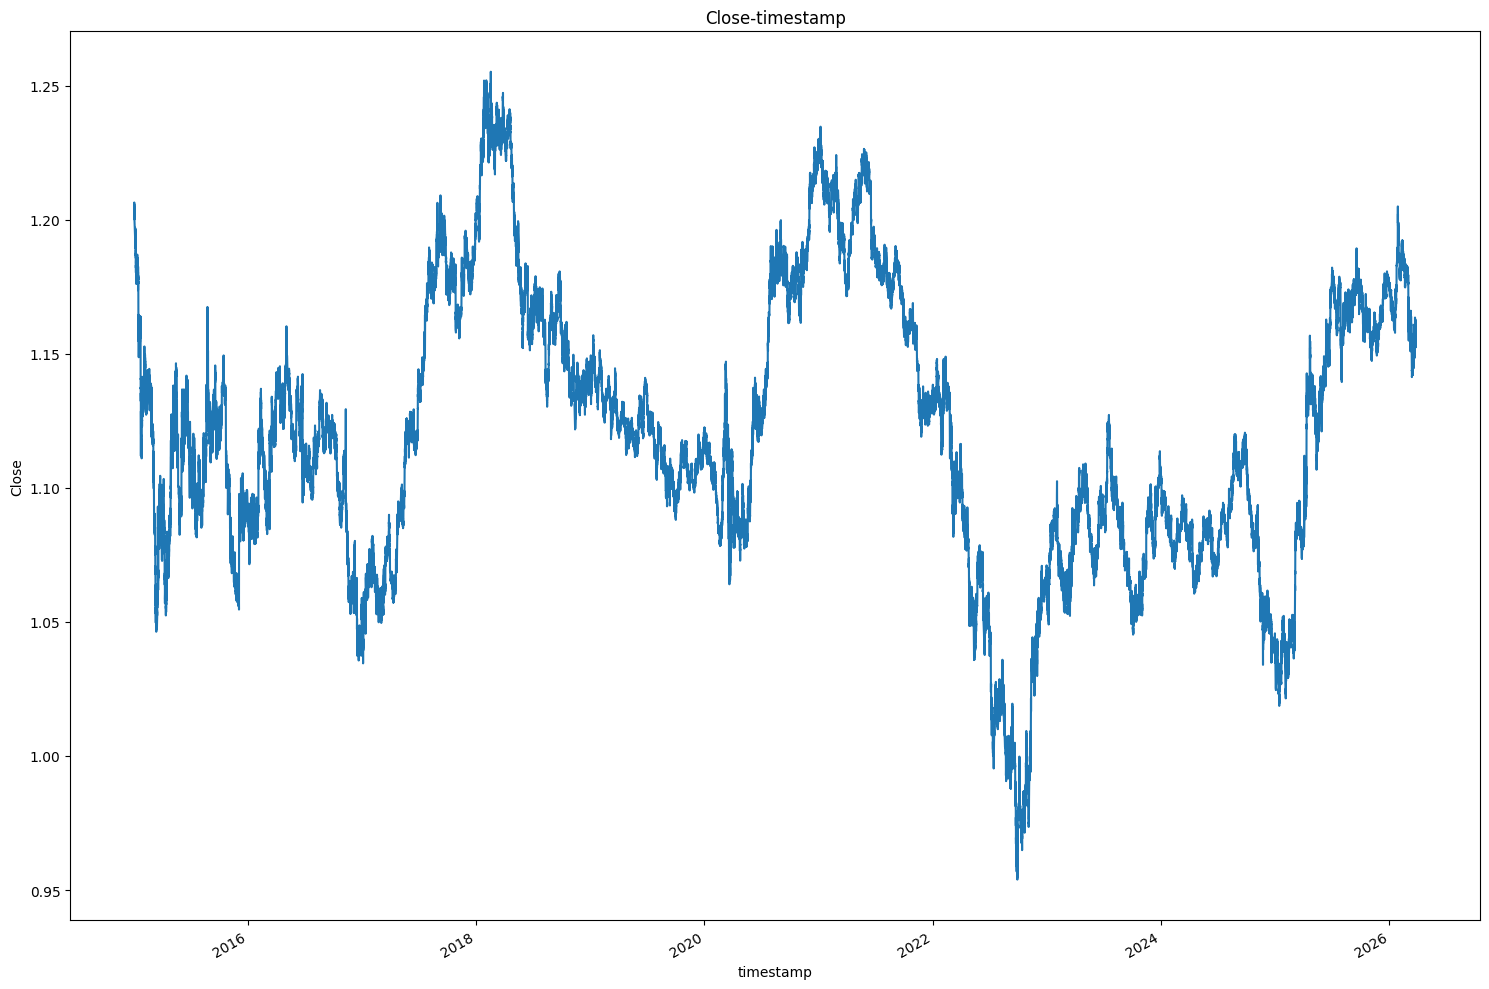

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize = (15,10))
plt.subplots_adjust(top=1.25, bottom =1.2)

plt.subplot()
df['close'].plot()
plt.ylabel('Close')
plt.xlabel('timestamp')
plt.title('Close-timestamp')
plt.tight_layout()

## 1.1 Event Detector

В этом разделе создаём rule-based Event Detector. Его задача — не предсказывать BUY/SELL, а отметить свечи, где вообще есть смысл запускать модель направления.

`event = 0` — обычная свеча, пропускаем.  
`event = 1` — есть событие, дальше можно запускать Direction Model.

In [8]:
# =========================
# EVENT DETECTOR: вспомогательные признаки
# =========================

# Важно: уровни для event detector лучше считать через shift(1),
# чтобы текущая свеча не создавала сама себе уровень.
# То есть уровень берется только из прошлых свечей.
df['prev_resistance_50'] = df['high'].rolling(50).max().shift(1)
df['prev_support_50'] = df['low'].rolling(50).min().shift(1)

# Расстояние до предыдущего сопротивления / поддержки.
# Чем меньше значение, тем ближе цена к уровню.
df['dist_to_prev_res'] = (df['prev_resistance_50'] - df['close']) / df['close']
df['dist_to_prev_sup'] = (df['close'] - df['prev_support_50']) / df['close']

# Размер свечи относительно цены.
df['candle_range'] = (df['high'] - df['low']) / df['open']
df['candle_body'] = abs(df['close'] - df['open']) / df['open']

# Средний размер свечи за прошлые 20 свечей.
# shift(1) — сравниваем текущую свечу с прошлой статистикой.
df['avg_range_20'] = df['candle_range'].rolling(20).mean().shift(1)
df['avg_body_20'] = df['candle_body'].rolling(20).mean().shift(1)

print('Event-признаки добавлены')
print(df[['close', 'prev_resistance_50', 'prev_support_50', 'dist_to_prev_res', 'dist_to_prev_sup', 'candle_range', 'avg_range_20']].tail())

Event-признаки добавлены
                       close  prev_resistance_50  prev_support_50  \
timestamp                                                           
2026-03-26 15:30:00  1.15328             1.15722          1.15223   
2026-03-26 15:45:00  1.15414             1.15722          1.15223   
2026-03-26 16:00:00  1.15423             1.15722          1.15223   
2026-03-26 16:15:00  1.15348             1.15722          1.15223   
2026-03-26 16:30:00  1.15370             1.15722          1.15223   

                     dist_to_prev_res  dist_to_prev_sup  candle_range  \
timestamp                                                               
2026-03-26 15:30:00          0.003416          0.000910      0.001135   
2026-03-26 15:45:00          0.002669          0.001655      0.000928   
2026-03-26 16:00:00          0.002590          0.001733      0.000537   
2026-03-26 16:15:00          0.003242          0.001084      0.001022   
2026-03-26 16:30:00          0.003051          0.0012

In [9]:
# =========================
# EVENT DETECTOR: CUSUM-фильтр
# =========================

# CUSUM — это НЕ нейросеть, а алгоритм поиска значимого накопленного движения.
# Он отмечает моменты, когда движение цены стало достаточно большим относительно текущей волатильности.

def add_cusum_events(dataframe, return_col='returns', volatility_window=96, threshold_mult=2.0):
    df_local = dataframe.copy()

    # Адаптивный порог: чем выше волатильность, тем больше движение нужно для события.
    # 96 свечей на 15m = примерно 1 день.
    df_local['cusum_threshold'] = (
        df_local[return_col]
        .rolling(volatility_window)
        .std()
        .shift(1) * threshold_mult
    )

    # Заполняем первые NaN медианным значением порога.
    median_threshold = df_local['cusum_threshold'].median()
    df_local['cusum_threshold'] = df_local['cusum_threshold'].fillna(median_threshold)

    pos_sum = 0.0
    neg_sum = 0.0

    events = []
    event_direction = []

    for ret, threshold in zip(df_local[return_col].fillna(0).values, df_local['cusum_threshold'].values):
        pos_sum = max(0.0, pos_sum + ret)
        neg_sum = min(0.0, neg_sum + ret)

        if pos_sum > threshold:
            events.append(1)
            event_direction.append(1)   # накопленное движение вверх
            pos_sum = 0.0
            neg_sum = 0.0

        elif neg_sum < -threshold:
            events.append(1)
            event_direction.append(-1)  # накопленное движение вниз
            pos_sum = 0.0
            neg_sum = 0.0

        else:
            events.append(0)
            event_direction.append(0)

    df_local['event_cusum'] = events
    df_local['event_cusum_direction'] = event_direction

    return df_local

# threshold_mult можно подбирать.
# Больше значение -> меньше событий.
# Меньше значение -> больше событий.
df = add_cusum_events(
    dataframe=df,
    return_col='returns',
    volatility_window=96,
    threshold_mult=3.0
)

print('CUSUM events:', df['event_cusum'].sum())
print(df[['returns', 'cusum_threshold', 'event_cusum', 'event_cusum_direction']].tail())

CUSUM events: 26468
                      returns  cusum_threshold  event_cusum  \
timestamp                                                     
2026-03-26 15:30:00 -0.000953         0.001092            1   
2026-03-26 15:45:00  0.000746         0.001114            0   
2026-03-26 16:00:00  0.000078         0.001138            0   
2026-03-26 16:15:00 -0.000650         0.001119            0   
2026-03-26 16:30:00  0.000191         0.001102            0   

                     event_cusum_direction  
timestamp                                   
2026-03-26 15:30:00                     -1  
2026-03-26 15:45:00                      0  
2026-03-26 16:00:00                      0  
2026-03-26 16:15:00                      0  
2026-03-26 16:30:00                      0  


In [10]:
# =========================
# EVENT DETECTOR: финальное правило event
# =========================

# Параметры можно подбирать.
near_level_threshold = 0.0005     # близость к уровню, примерно 5 пунктов для EURUSD
strong_range_multiplier = 2     # текущая свеча больше среднего range в 2 раза
strong_body_multiplier = 1.8      # тело свечи больше среднего body в 1.8 раза

# Цена рядом с прошлым сопротивлением или поддержкой.
df['near_resistance'] = df['dist_to_prev_res'].abs() < near_level_threshold
df['near_support'] = df['dist_to_prev_sup'].abs() < near_level_threshold
df['near_level'] = df['near_resistance'] | df['near_support']

# Сильная свеча: range или тело больше обычного.
df['strong_range'] = df['candle_range'] > df['avg_range_20'] * strong_range_multiplier
df['strong_body'] = df['candle_body'] > df['avg_body_20'] * strong_body_multiplier
df['strong_candle'] = df['strong_range'] | df['strong_body']

# Пробой прошлых уровней.
df['breakout_up'] = df['close'] > df['prev_resistance_50']
df['breakout_down'] = df['close'] < df['prev_support_50']
df['breakout'] = df['breakout_up'] | df['breakout_down']

# Финальный event:
# событие есть, если CUSUM заметил значимое движение
# и одновременно есть рыночный контекст: уровень / сильная свеча / пробой.
df['event'] = (
    (df['event_cusum'] == 1) &
    (df['near_level'] | df['strong_candle'] | df['breakout'])
).astype(int)

# После новых rolling-признаков могли появиться NaN.
df = df.dropna()

print('Всего строк:', len(df))
print('Всего event=1:', df['event'].sum())
print('Доля event=1:', round(df['event'].mean() * 100, 4), '%')

print('Последние события:')
display(df[df['event'] == 1][[
    'open', 'high', 'low', 'close',
    'event_cusum_direction',
    'near_level', 'strong_candle', 'breakout',
    'dist_to_prev_res', 'dist_to_prev_sup'
]].tail(10))

Всего строк: 277006
Всего event=1: 19535
Доля event=1: 7.0522 %
Последние события:


,open,high,low,close,event_cusum_direction,near_level,strong_candle,breakout,dist_to_prev_res,dist_to_prev_sup
timestamp,,,,,,,,,,
2026-03-25 08:00:00,1.15977,1.16082,1.15906,1.16063,1,False,True,False,0.002085,0.002033
2026-03-25 12:30:00,1.15952,1.15980,1.15905,1.15916,-1,True,False,False,0.003356,0.000423
2026-03-25 13:45:00,1.15802,1.15813,1.15716,1.15728,-1,True,True,True,0.004450,-0.000493
2026-03-25 15:30:00,1.15748,1.15779,1.15651,1.15677,-1,True,False,False,0.004219,0.000173
2026-03-25 19:00:00,1.15663,1.15663,1.15590,1.15607,-1,True,False,False,0.004827,0.000476
2026-03-26 05:45:00,1.15637,1.15637,1.15575,1.15577,-1,True,True,False,0.002241,0.000329
2026-03-26 08:00:00,1.15536,1.15536,1.15474,1.15527,-1,True,False,False,0.001688,0.000190
2026-03-26 11:15:00,1.15510,1.15526,1.15429,1.15437,-1,True,True,True,0.002469,-0.000321
2026-03-26 11:45:00,1.15334,1.15341,1.15232,1.15241,-1,False,True,True,0.004174,-0.000686


In [11]:
# =========================
# EVENT DETECTOR: сколько сигналов в день
# =========================

signals_per_day = df['event'].resample('1D').sum()

print('Статистика сигналов в день:')
print(signals_per_day.describe())

print('Среднее сигналов в день:', round(signals_per_day.mean(), 3))
print('Медиана сигналов в день:', round(signals_per_day.median(), 3))
print('Максимум сигналов в день:', int(signals_per_day.max()))

# Удобно посмотреть дни, где сигналов слишком много.
print('Топ-10 дней по количеству событий:')
display(signals_per_day.sort_values(ascending=False).head(10))

Статистика сигналов в день:
count    4102.000000
mean        4.762311
std         3.499512
min         0.000000
25%         1.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: event, dtype: float64
Среднее сигналов в день: 4.762
Медиана сигналов в день: 5.0
Максимум сигналов в день: 17
Топ-10 дней по количеству событий:


timestamp
2022-02-24    17
2023-08-29    16
2019-12-27    15
2021-09-07    15
2021-02-16    14
2025-07-07    14
2016-10-11    14
2019-08-05    14
2021-11-26    14
2023-02-21    14
Name: event, dtype: int64

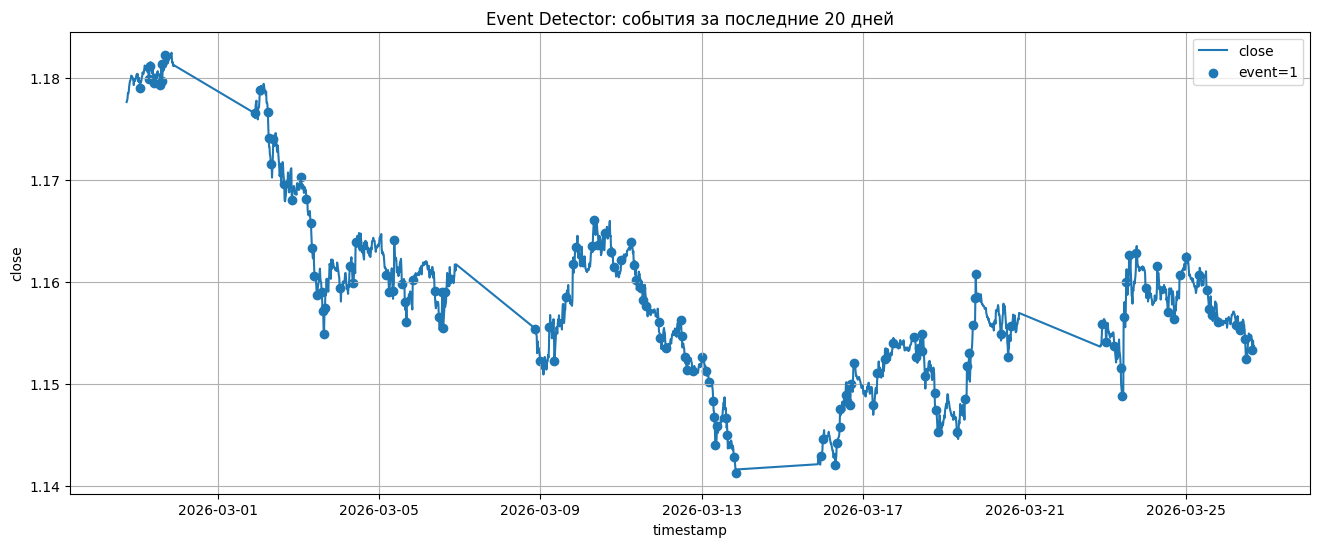

In [12]:
# =========================
# EVENT DETECTOR: быстрый график последних событий
# =========================

import matplotlib.pyplot as plt

plot_days = 20
plot_df = df.tail(96 * plot_days).copy()
events_df = plot_df[plot_df['event'] == 1]

plt.figure(figsize=(16, 6))
plt.plot(plot_df.index, plot_df['close'], label='close')
plt.scatter(events_df.index, events_df['close'], marker='o', label='event=1')
plt.title(f'Event Detector: события за последние {plot_days} дней')
plt.xlabel('timestamp')
plt.ylabel('close')
plt.legend()
plt.grid(True)
plt.show()

### Как интерпретировать результат

Ориентир для 15-минутного EURUSD:

- `0–1` событие в день — фильтр слишком строгий;
- `1–5` событий в день — нормальный рабочий диапазон;
- `10+` событий в день — фильтр слишком мягкий, будет много шума.

Подбирать в первую очередь:

- `threshold_mult`: больше → меньше CUSUM-событий;
- `near_level_threshold`: меньше → строже близость к уровню;
- `strong_range_multiplier`: больше → только более сильные свечи.

# 2. 

# 2.1 Импорты 

In [33]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

#Проверка GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 2.2 Подготовка данных

In [34]:
train_df = df[df.index < '2021-01-01']
val_df = df[(df.index >= '2021-01-01') & (df.index < '2024-01-01')]
test_df = df[df.index >= '2024-01-01']

In [35]:
# масшатабирование
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_df)
scaled_val = scaler.transform(val_df)
scaled_test = scaler.transform(test_df)

# преобразование в тензоры
train_data = torch.FloatTensor(scaled_train) # хранится на cpu, чтоб gpu не был постоянно загружен. 
val_data = torch.FloatTensor(scaled_val)
test_data = torch.FloatTensor(scaled_test)
#чтоб перенести на gpu .to(device)

## 2.3 Создание последовательности

In [36]:
# параметры для формирования последовательностей
sequence_length = 64
batch_size = 256

# для торгового робота практичнее предсказывать не абсолютную цену следующей свечи,
# а направление следующей свечи: вырастет close или нет.
# Причины выбора:
# 1) торговое решение чаще сводится к buy / sell / hold;
# 2) классификация направления обычно устойчивее, чем регрессия точной цены;
# 3) не требуется обратное масштабирование целевой переменной.
#
# Метка:
# y = 1, если close_next > close_current
# y = 0, если close_next <= close_current

# если в данных есть OHLCV, используем их как признаки.
# если набор столбцов отличается, берем все доступные столбцы.
preferred_feature_columns = ['open', 'high', 'low', 'close', 'volume']
feature_columns = [col for col in preferred_feature_columns if col in train_df.columns]

if len(feature_columns) == 0:
    feature_columns = train_df.columns.tolist()

# целевой столбец для расчета направления
if 'close' in train_df.columns:
    target_column = 'close'
else:
    target_column = feature_columns[-1]
    print(f'Столбец close не найден. В качестве целевого столбца используется: {target_column}')

feature_indices = [train_df.columns.get_loc(col) for col in feature_columns]

# оставляем только нужные признаки в том порядке, который будет использоваться моделью
train_features = train_data[:, feature_indices]
val_features = val_data[:, feature_indices]
test_features = test_data[:, feature_indices]

print('Используемые признаки:', feature_columns)
print('Целевой столбец:', target_column)
print('Размер train_features:', train_features.shape)
print('Размер val_features:', val_features.shape)
print('Размер test_features:', test_features.shape)

Используемые признаки: ['open', 'high', 'low', 'close', 'volume']
Целевой столбец: close
Размер train_features: torch.Size([147965, 5])
Размер val_features: torch.Size([73937, 5])
Размер test_features: torch.Size([55104, 5])


In [37]:
class TimeSeriesDataset(Dataset):
    def __init__(self, feature_tensor, close_series, sequence_length):
        self.feature_tensor = feature_tensor
        self.close_values = np.asarray(close_series, dtype=np.float32)
        self.sequence_length = sequence_length

        # для последовательности длины sequence_length нужен еще 1 следующий шаг для целевой метки
        if len(self.feature_tensor) != len(self.close_values):
            raise ValueError('Длина feature_tensor и close_series должна совпадать.')

        if len(self.feature_tensor) <= self.sequence_length:
            raise ValueError('Длина ряда должна быть больше sequence_length.')

    def __len__(self):
        # количество доступных окон
        return len(self.feature_tensor) - self.sequence_length

    def __getitem__(self, idx):
        # X: окно предыдущих наблюдений
        x = self.feature_tensor[idx : idx + self.sequence_length]

        # индекс свечи, направление которой предсказываем
        target_idx = idx + self.sequence_length

        # y: направление следующей свечи относительно последней свечи в окне
        y = 1.0 if self.close_values[target_idx] > self.close_values[target_idx - 1] else 0.0
        y = torch.tensor([y], dtype=torch.float32)

        return x, y


# создаем Dataset для каждого сплита независимо, чтобы не было утечки данных через границы выборок
train_dataset = TimeSeriesDataset(
    feature_tensor=train_features,
    close_series=train_df[target_column].values,
    sequence_length=sequence_length
)

val_dataset = TimeSeriesDataset(
    feature_tensor=val_features,
    close_series=val_df[target_column].values,
    sequence_length=sequence_length
)

test_dataset = TimeSeriesDataset(
    feature_tensor=test_features,
    close_series=test_df[target_column].values,
    sequence_length=sequence_length
)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False) # shuffle=True 
# нужен, тк Мы не мешаем временной порядок внутри последовательности
# Мы мешаем только порядок самих окон
# Без shuffle:окна идут подряд: [0:64], [1:65], [2:66], ... Что усилит момент переобучения

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

print(f'Количество train-последовательностей: {len(train_dataset)}')
print(f'Количество val-последовательностей: {len(val_dataset)}')
print(f'Количество test-последовательностей: {len(test_dataset)}')

Количество train-последовательностей: 147901
Количество val-последовательностей: 73873
Количество test-последовательностей: 55040


In [38]:

# проверка размеров тензоров на одном batch
x_batch, y_batch = next(iter(train_loader))

print('Размер X batch:', x_batch.shape)   # [batch_size, sequence_length, input_size]
print('Размер y batch:', y_batch.shape)   # [batch_size, 1]

assert x_batch.ndim == 3, 'X должен иметь размерность [batch_size, sequence_length, input_size]'
assert y_batch.ndim == 2, 'y должен иметь размерность [batch_size, 1]'
assert x_batch.shape[1] == sequence_length, 'Вторая размерность X должна быть равна sequence_length'
assert x_batch.shape[2] == len(feature_columns), 'Третья размерность X должна совпадать с числом признаков'

print('Проверка размеров пройдена успешно.')

Размер X batch: torch.Size([256, 64, 5])
Размер y batch: torch.Size([256, 1])
Проверка размеров пройдена успешно.


## 2.4 Создание модели GRU 

In [39]:
# параметры модели и обучения
input_size = len(feature_columns)
hidden_size = 128
num_layers = 2
dropout = 0.2
num_epochs = 50
learning_rate = 1e-3
patience = 7

# выбор устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Используемое устройство:', device)

Используемое устройство: cuda


In [40]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()

        # dropout внутри GRU работает только если num_layers > 1
        gru_dropout = dropout if num_layers > 1 else 0.0

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=gru_dropout
        )

        # финальный слой выдает 1 логит для бинарной классификации направления
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: [batch_size, sequence_length, input_size]
        out, _ = self.gru(x)

        # берем выход только по последнему шагу последовательности
        out = out[:, -1, :]  # [batch_size, hidden_size]
        out = self.fc(out)   # [batch_size, 1]

        return out


model = GRUModel(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=dropout
).to(device)

print(model)

# итоговая архитектура модели
print('\nАрхитектура модели:')
print(f'input_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}, dropout={dropout}')

GRUModel(
  (gru): GRU(5, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Архитектура модели:
input_size=5, hidden_size=128, num_layers=2, dropout=0.2


In [41]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

best_val_loss = float('inf')
early_stopping_counter = 0
train_losses = []
val_losses = []

model_save_path = 'gru_model_best.pth'
scaler_save_path = 'gru_scaler.pkl'

In [42]:
import pickle

for epoch in range(num_epochs):
    # =========================
    # обучение
    # =========================
    model.train()
    running_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * x_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # =========================
    # валидация
    # =========================
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            running_val_loss += loss.item() * x_batch.size(0)

    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)

    print(
        f'Epoch [{epoch + 1}/{num_epochs}] | '
        f'train_loss: {epoch_train_loss:.6f} | '
        f'val_loss: {epoch_val_loss:.6f}'
    )

    # =========================
    # early stopping + сохранение лучших весов
    # =========================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        early_stopping_counter = 0

        # сохраняем лучшие веса модели
        torch.save(model.state_dict(), model_save_path)

        # отдельно сохраняем scaler, чтобы потом использовать его в торговом роботе
        with open(scaler_save_path, 'wb') as f:
            pickle.dump(scaler, f)

        print(f'  -> Найдена лучшая модель. Веса сохранены в: {model_save_path}')
    else:
        early_stopping_counter += 1
        print(f'  -> Улучшения нет. Счетчик early stopping: {early_stopping_counter}/{patience}')

        if early_stopping_counter >= patience:
            print('Early stopping сработал. Обучение остановлено.')
            break

print(f'\nЛучшее значение val_loss: {best_val_loss:.6f}')
print(f'Путь к сохраненным весам: {model_save_path}')
print(f'Путь к сохраненному scaler: {scaler_save_path}')

Epoch [1/50] | train_loss: 0.693296 | val_loss: 0.693026
  -> Найдена лучшая модель. Веса сохранены в: gru_model_best.pth
Epoch [2/50] | train_loss: 0.693167 | val_loss: 0.693002
  -> Найдена лучшая модель. Веса сохранены в: gru_model_best.pth
Epoch [3/50] | train_loss: 0.693138 | val_loss: 0.693033
  -> Улучшения нет. Счетчик early stopping: 1/7
Epoch [4/50] | train_loss: 0.693143 | val_loss: 0.693027
  -> Улучшения нет. Счетчик early stopping: 2/7
Epoch [5/50] | train_loss: 0.693118 | val_loss: 0.693052
  -> Улучшения нет. Счетчик early stopping: 3/7
Epoch [6/50] | train_loss: 0.693125 | val_loss: 0.693019
  -> Улучшения нет. Счетчик early stopping: 4/7
Epoch [7/50] | train_loss: 0.693126 | val_loss: 0.693019
  -> Улучшения нет. Счетчик early stopping: 5/7
Epoch [8/50] | train_loss: 0.693110 | val_loss: 0.693391
  -> Улучшения нет. Счетчик early stopping: 6/7
Epoch [9/50] | train_loss: 0.693140 | val_loss: 0.693033
  -> Улучшения нет. Счетчик early stopping: 7/7
Early stopping сработ

In [43]:
# загрузка лучших сохраненных весов обратно в модель
loaded_model = GRUModel(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=dropout
).to(device)

loaded_model.load_state_dict(torch.load(model_save_path, map_location=device))
loaded_model.eval()

with open(scaler_save_path, 'rb') as f:
    loaded_scaler = pickle.load(f)

print('Лучшие веса и scaler успешно загружены обратно.')

Лучшие веса и scaler успешно загружены обратно.


In [44]:
# пример инференса на новых данных
# берем последнюю последовательность из test-части
last_sequence = test_features[-sequence_length:].unsqueeze(0).to(device)

print('Размер last_sequence:', last_sequence.shape)  # [1, sequence_length, input_size]

loaded_model.eval()
with torch.no_grad():
    logits = loaded_model(last_sequence)
    probability_up = torch.sigmoid(logits).item()
    predicted_class = 1 if probability_up >= 0.5 else 0

print(f'Вероятность роста следующей свечи: {probability_up:.6f}')
print(f'Предсказанный класс: {predicted_class}')
print('Интерпретация: 1 = следующая свеча вверх, 0 = следующая свеча вниз или без роста')

# так как модель предсказывает направление, обратное масштабирование результата не требуется.
# однако для удобства можно получить последнее фактическое значение close в исходном масштабе.
last_close_original = test_df[target_column].iloc[-1]
print(f'Последнее доступное значение {target_column} в исходном масштабе: {last_close_original}')

Размер last_sequence: torch.Size([1, 64, 5])
Вероятность роста следующей свечи: 0.490729
Предсказанный класс: 0
Интерпретация: 1 = следующая свеча вверх, 0 = следующая свеча вниз или без роста
Последнее доступное значение close в исходном масштабе: 1.1537


In [45]:
# пример вспомогательной функции для интеграции в торгового робота
# на вход подается DataFrame с теми же столбцами, что использовались при обучении.
def predict_next_candle_direction(recent_df, model, scaler, feature_columns, sequence_length, device):
    if len(recent_df) < sequence_length:
        raise ValueError(f'Для прогноза нужно минимум {sequence_length} строк.')

    # берем только нужные признаки и сохраняем порядок столбцов
    model_input_df = recent_df[train_df.columns].copy()

    # применяем тот же scaler, который использовался на обучении
    scaled_recent = scaler.transform(model_input_df)
    scaled_recent = torch.FloatTensor(scaled_recent)

    # оставляем только признаки, которые реально подаются в модель
    feature_indices = [train_df.columns.get_loc(col) for col in feature_columns]
    scaled_recent = scaled_recent[:, feature_indices]

    # берем последнее окно
    sequence = scaled_recent[-sequence_length:].unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(sequence)
        probability_up = torch.sigmoid(logits).item()
        predicted_class = 1 if probability_up >= 0.5 else 0

    return {
        'probability_up': probability_up,
        'predicted_class': predicted_class,
        'signal': 'BUY' if predicted_class == 1 else 'SELL'
    }


# пример вызова функции
example_result = predict_next_candle_direction(
    recent_df=test_df.tail(sequence_length + 10),
    model=loaded_model,
    scaler=loaded_scaler,
    feature_columns=feature_columns,
    sequence_length=sequence_length,
    device=device
)

print('Пример результата для торгового робота:', example_result)
print(f'Итоговый путь к сохраненным весам: {model_save_path}')

Пример результата для торгового робота: {'probability_up': 0.4907286763191223, 'predicted_class': 0, 'signal': 'SELL'}
Итоговый путь к сохраненным весам: gru_model_best.pth
